In [3]:
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import phi2D_utilities as utils;

# Styling.
plt.style.use("ggplot");

In [4]:
# Test inputs - delete when done!
delta_t = reader.fetch_data_from_h5("C:/Workspace/NSCC/local copies/raw_output_data/DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.3/sp0/Phi2D/Phi2D_d00000.h5")["deltat"].values;
data_arrays = reader.compile_data_from_directory("Phirth_n0", "C:/Workspace/NSCC/local copies/raw_output_data/DN_DAYCASE_DELTASCAN_255X512_Q3.5_-0.3/sp0/Phi2D");

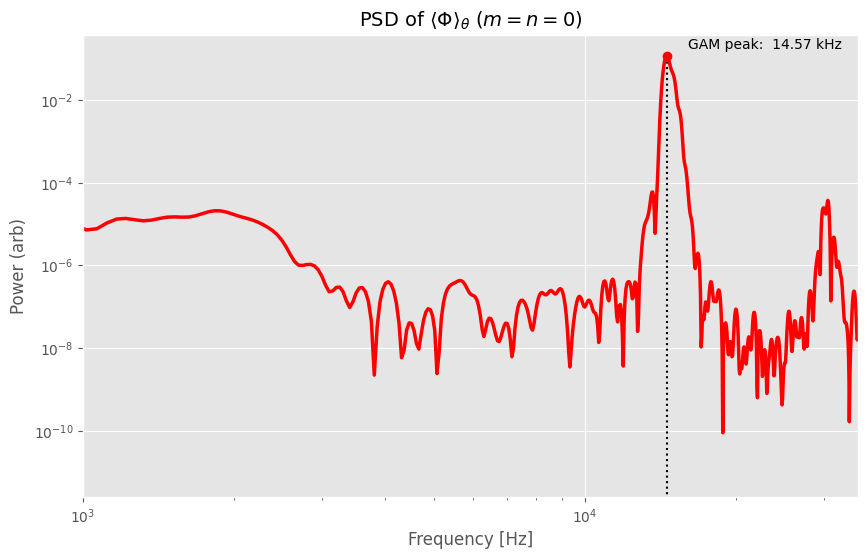

In [14]:
def plot_power_spectrum_density(phi2D_list, delta_t, effective_radius = 0.7):

	# Signal isolation and data processing.
	# Logic here is similar to that of `extract_GAM_frequency` in the utilities.
	radial_time_series = utils.generate_poloidally_averaged_time_series(phi2D_list, effective_radius);
	frequencies, power_spectrum_density = utils.map_power_spectrum(radial_time_series, delta_t);
	frequencies = utils.convert_to_real_frequency(frequencies);
	GAM_peak_index = utils.isolate_GAM_peak_index(power_spectrum_density, frequencies);
	GAM_frequency = frequencies[GAM_peak_index];
	GAM_power = float(power_spectrum_density[GAM_peak_index]);
	
	# Figure plotting logic.
	plt.figure(figsize = (10, 6));
	plt.loglog(frequencies, power_spectrum_density, label = "PSD", color = "red", lw = 2.5);
	plt.vlines(GAM_frequency, GAM_power, 0, colors = "black", linestyles = "dotted");
	plt.plot(GAM_frequency, power_spectrum_density[GAM_peak_index], "ro");
	plt.annotate(f"GAM peak: {GAM_frequency/1e3 : .2f} kHz", xy = (GAM_frequency, GAM_power), xytext = (GAM_frequency * 1.1, GAM_power * 1.5));
	plt.xlim(1000, 35000);
	plt.xlabel("Frequency [Hz]");	
	plt.ylabel("Power (arb)");
	plt.title(r"PSD of $\langle \Phi \rangle_\theta$ ($m = n = 0$)", fontsize = 14);
	plt.show();

plot_power_spectrum_density(data_arrays, delta_t);